# CRISP-DM: Reintegration Readiness

**Analytics goal:** Identify residents **approaching reintegration readiness** and factors associated with progression—so case management can time support, staffing, and external coordination safely.

| CRISP-DM phase | Where it appears |
|----------------|------------------|
| **1. Business understanding** | Next section + Business KPI mapping |
| **2. Data understanding** | Resident snapshot, audits, visuals |
| **3. Data preparation** | `src.features` (resident-level feature matrix) |
| **4. Modeling** | Predictive + explanatory models |
| **5. Evaluation** | Metrics, threshold/cost framing, ethics |
| **6. Deployment** | Readiness scores for case workflows |

### 1) Business understanding (reintegration readiness)

**Organizational context:** Reintegration—moving toward life outside the program—is a **high-stakes transition** for residents and for Lighthouse Sanctuary’s duty of care. Staff must balance **empowerment** (preparing residents) with **safety** (not rushing transitions when risk remains).

**Business objectives**
- Allocate **case management time** and **external referrals** (housing, employment, education) toward residents who are **most ready to benefit** from intensive transition planning.
- Improve **successful progression** through defined readiness milestones while **not increasing** serious incidents or unsafe transitions.

**Stakeholders and decisions**
| Stakeholder | Decision enabled |
|-------------|------------------|
| **Case Management Director / social workers** | Caseload prioritization, meeting cadence, referral timing |
| **Program leadership** | Capacity planning and risk oversight |
| **Residents (indirectly)** | Fair, transparent prioritization—scores support staff judgment, not replace it |

**Measurable success criteria (examples aligned with KPI mapping)**
- **+7%** (or agreed lift) in **readiness progression** among appropriately supported residents, with **no increase** in severe incident rate during transition prep (guardrail).

**Constraints (especially ethics)**
- **Non-discrimination & dignity:** Models must not become punitive labels; residents deserve context and staff relationship, not algorithmic “worthiness.”
- **Safety first:** False negatives (missed risk) and false positives (overconfidence in readiness) both carry **human** consequences—evaluation must discuss error types in **case-management language**, not only ROC curves.
- **Data limits:** Administrative records may not capture trauma, health, or family complexity fully.

**Costs of errors**
- **False positive readiness:** Premature transition planning—stress, failed placements, reputational and human harm.
- **False negative:** Delayed support for someone who could safely progress—opportunity cost and equity concerns.

**Use of outputs:** Triage and **conversation starters** for case conferences, not standalone discharge decisions.

In [1]:
import os, sys
from pathlib import Path


def _find_ml_pipelines_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        mp = base / "ml-pipelines"
        if mp.is_dir() and (mp / "requirements.txt").is_file():
            return mp
        if base.name == "ml-pipelines" and (base / "requirements.txt").is_file():
            return base
    raise RuntimeError(
        "Could not find ml-pipelines/requirements.txt. Open the Lighthouse-Sanctuary repo "
        "or the ml-pipelines folder, then use Run All."
    )


_boot_path = _find_ml_pipelines_root() / "pipeline_common" / "notebook_bootstrap.py"
_ns = globals()
_ns["__file__"] = str(_boot_path)
exec(compile(_boot_path.read_text(encoding="utf-8"), str(_boot_path), "exec"), _ns)

import pandas as pd

from src.db import load_env, build_engine
from src.features import build_frame, split_xy
from src.modeling import train_models


## Business KPI mapping (operational measures)

These bullets make the **business objectives** in Business understanding measurable for programs and leadership.

- Stakeholder owner: Case Management Director
- Decision enabled: prioritize residents for reintegration preparation support
- Primary KPI: successful reintegration progression rate
- Guardrail KPIs: adverse incidents during transition, staff overload index
- Minimum success criteria: +7% readiness progression with no increase in severe incident rate

## Problem Framing
- Predictive: classify residents approaching reintegration readiness.
- Explanatory: identify education, health, and counseling factors associated with readiness.
- This helps prioritize social-worker interventions.

In [2]:
load_env('.env')
engine = build_engine(os.getenv('DB_PROFILE', 'local'))
df = build_frame(engine)
X, y = split_xy(df)
print(df.shape, 'readiness rate=', round(y.mean(),4))
df.head()

ModuleNotFoundError: No module named 'duckdb'

In [ ]:
# Data Understanding Audit: missingness + anomaly checks
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(10).to_frame('missing_pct'))

audit = {
    'rows': len(df),
    'readiness_positive_rate': float(y.mean()),
    'invalid_attendance_rows': int(((df['attendance_avg'] < 0) | (df['attendance_avg'] > 1)).sum()),
    'invalid_health_rows': int(((df['health_avg'] < 0) | (df['health_avg'] > 5)).sum()),
}
print('Audit summary:', audit)

print('Feature rationale: education, health, and counseling metrics represent reintegration preparation domains.')

,missing_pct
resident_id,0.0
case_status,0.0
reintegration_status,0.0
current_risk_level,0.0
edu_progress_avg,0.0
attendance_avg,0.0
health_avg,0.0
energy_avg,0.0
session_minutes_avg,0.0
progress_noted_rate,0.0


Audit summary: {'rows': 60, 'readiness_positive_rate': 0.6666666666666666, 'invalid_attendance_rows': 0, 'invalid_health_rows': 0}
Feature rationale: education, health, and counseling metrics represent reintegration preparation domains.


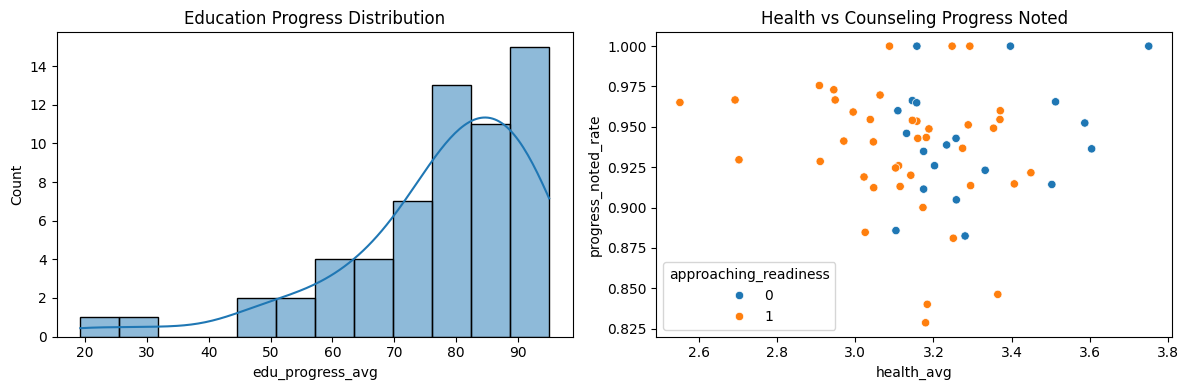

In [ ]:
import numpy as np
import subprocess
import sys

try:
    import seaborn as sns
    import matplotlib.pyplot as plt
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn', 'matplotlib'])
    import seaborn as sns
    import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['edu_progress_avg'], bins=12, kde=True, ax=axes[0])
axes[0].set_title('Education Progress Distribution')

sns.scatterplot(data=df, x='health_avg', y='progress_noted_rate', hue='approaching_readiness', ax=axes[1])
axes[1].set_title('Health vs Counseling Progress Noted')
plt.tight_layout()
plt.show()

In [ ]:
rf, rf_metrics, lg, lg_metrics, coef_df = train_models(X, y)
print('Predictive RF metrics:', {k: round(v,4) for k,v in rf_metrics.items()})
print('Explanatory logistic metrics:', {k: round(v,4) for k,v in lg_metrics.items()})
display(coef_df.head(12))
display(coef_df.tail(12).sort_values('coefficient'))

Predictive RF metrics: {'roc_auc': 0.64, 'pr_auc': 0.8006}
Explanatory logistic metrics: {'roc_auc': 0.76, 'pr_auc': 0.8947}


,feature,coefficient,odds_ratio
0,num__edu_progress_avg,0.444959,1.560427
3,num__energy_avg,0.378437,1.460000
10,cat__current_risk_level_Medium,0.324230,1.382966
7,cat__current_risk_level_Critical,0.118499,1.125806
4,num__session_minutes_avg,0.078773,1.081958
6,num__concerns_rate,0.024883,1.025195
5,num__progress_noted_rate,-0.021253,0.978972
8,cat__current_risk_level_High,-0.067465,0.934760
9,cat__current_risk_level_Low,-0.373403,0.688388
1,num__attendance_avg,-0.501356,0.605709


,feature,coefficient,odds_ratio
2,num__health_avg,-1.275131,0.279394
1,num__attendance_avg,-0.501356,0.605709
9,cat__current_risk_level_Low,-0.373403,0.688388
8,cat__current_risk_level_High,-0.067465,0.934760
5,num__progress_noted_rate,-0.021253,0.978972
6,num__concerns_rate,0.024883,1.025195
4,num__session_minutes_avg,0.078773,1.081958
7,cat__current_risk_level_Critical,0.118499,1.125806
10,cat__current_risk_level_Medium,0.324230,1.382966
3,num__energy_avg,0.378437,1.460000


In [ ]:
# Threshold tuning + FP/FN cost table for readiness classifier
readiness_proba_full = lg.predict_proba(X)[:, 1]
thresholds = np.arange(0.1, 0.95, 0.05)
fp_cost = 1.5
fn_cost = 4.0
rows = []
for t in thresholds:
    pred = (readiness_proba_full >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    total_cost = fp_cost * fp + fn_cost * fn
    rows.append({'threshold': round(float(t), 2), 'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn), 'total_cost': float(total_cost)})

cost_df = pd.DataFrame(rows).sort_values('total_cost').reset_index(drop=True)
display(cost_df.head(10))
best_t = float(cost_df.loc[0, 'threshold'])
print(f'Selected threshold by cost minimization: {best_t:.2f}')

,threshold,tp,fp,fn,tn,total_cost
0,0.25,40,16,0,4,24.0
1,0.20,40,17,0,3,25.5
2,0.15,40,18,0,2,27.0
3,0.10,40,19,0,1,28.5
4,0.30,38,15,2,5,30.5
5,0.35,38,15,2,5,30.5
6,0.50,36,11,4,9,32.5
7,0.45,36,12,4,8,34.0
8,0.40,37,15,3,5,34.5
9,0.55,34,9,6,11,37.5


Selected threshold by cost minimization: 0.25


## Evaluation In Business Terms
- False positives: resources allocated to residents not yet ready.
- False negatives: delayed support for residents nearing readiness.
Use outputs to prioritize case conferences and targeted support plans.

## Operationalization Policy + Monitoring

- Threshold policy: use minimum-cost threshold from FP/FN table; default fallback 0.55.
- Action bands: high readiness -> immediate case conference, medium -> targeted support plan, low -> intensified monitoring.
- Retraining cadence: monthly retrain; early retrain if PR-AUC floor breach or data drift alert.
- Monitoring references:
  - `ml-pipelines/integration/pipeline_registry.yaml`
  - `ml-pipelines/integration/monitoring_spec.md`
  - `ml-pipelines/integration/README.md`

## Causal Caveat
Observed associations are not proof of causal readiness drivers.

## Deployment Notes
Surface readiness probability in case-management dashboard with drill-down to top contributing factors.